# Gaussian Processes Summer School

## Part 4: Paired-RFF GPLVMs on MNIST and Fashion-MNIST

We compare three spectral families inside the same amortized variational GPLVM: an RBF kernel, a tunable mixture of locally periodic kernels, and the implicit neural spectral sampler introduced in Part 3. Every model uses $q(W)=p_\theta(W)$ and paired cosine/sine random Fourier features without random phases.


## 1. Amortized variational GPLVM with $q(W)=p(W)$

Let $Y\in\mathbb R^{N\times D}$ contain $N$ vectorized images, with $D=784$, and choose a latent dimension $K$. The GPLVM assumes

$$\mathbf x_n\sim\mathcal N(\mathbf0,I_K),\qquad f_d(\cdot)\sim\mathcal{GP}(0,k_\theta),\qquad y_{nd}=f_d(\mathbf x_n)+\epsilon_{nd}.$$

The $D$ pixel functions are conditionally independent but share the latent coordinates and kernel. A common encoder amortizes inference over images:

$$q_\phi(\mathbf x_n\mid\mathbf y_n)=\mathcal N\!\left(\boldsymbol\mu_\phi(\mathbf y_n),\operatorname{diag}(\boldsymbol\sigma_\phi^2(\mathbf y_n))\right).$$

The Fourier frequencies are not assigned a separate data-adapted variational posterior. We set

$$q(W)=p_\theta(W),\qquad \mathrm{KL}[q(W)\|p_\theta(W)]=0,$$

and optimize the Monte Carlo ELBO

$$\mathcal L=\mathbb E_{q_\phi(X\mid Y)p_\theta(W)}[\log p(Y\mid X,W)]-\mathrm{KL}[q_\phi(X\mid Y)\|p(X)].$$

Fresh reparameterized samples of $X$ and $W$ are drawn during training. Gradients through $W$ learn the parameters $\theta$ of the spectral prior; this is empirical Bayes, not variational inference over individual frequencies.


## 2. Paired cosine/sine random Fourier features

For a stationary kernel, Bochner's theorem gives

$$k_\theta(\mathbf x,\mathbf x')=\mathbb E_{\mathbf w\sim p_\theta}[\cos(\mathbf w^\top(\mathbf x-\mathbf x'))].$$

After drawing $L$ frequencies $\mathbf w_l\sim p_\theta$, we use the paired feature map

$$\phi_\theta(\mathbf x)=\frac1{\sqrt L}[\cos(\mathbf w_1^\top\mathbf x),\sin(\mathbf w_1^\top\mathbf x),\ldots,\cos(\mathbf w_L^\top\mathbf x),\sin(\mathbf w_L^\top\mathbf x)]^\top.$$

There are $2L$ real features. No random phase is necessary because

$$\cos(\mathbf w^\top\mathbf x)\cos(\mathbf w^\top\mathbf x')+\sin(\mathbf w^\top\mathbf x)\sin(\mathbf w^\top\mathbf x')=\cos(\mathbf w^\top(\mathbf x-\mathbf x')).$$

Consequently,

$$K_X\approx F F^\top,\qquad F=\sqrt{\sigma_f^2}\,\Phi_\theta(X).$$

The feature weights for the $D$ output functions are analytically marginalized. The matrix determinant lemma and Woodbury identity reduce the likelihood calculation to a $2L\times2L$ system; the implementation never constructs an $N\times N$ covariance matrix.


## 3. Spectral models being compared

### RBF

$$p_\theta(\mathbf w)=\mathcal N(\mathbf0,\operatorname{diag}(\boldsymbol\ell^{-2})),$$

which implies the ARD RBF kernel

$$k_{\mathrm{RBF}}(\boldsymbol\tau)=\sigma_f^2\exp\left[-\frac12\sum_{j=1}^K\frac{\tau_j^2}{\ell_j^2}\right].$$

### Mixture of $M$ locally periodic kernels

The second model learns

$$k_{\mathrm{mix}}(\boldsymbol\tau)=\sigma_f^2\sum_{m=1}^M\rho_m\exp\left[-\frac12\sum_{j=1}^K s_{mj}^2\tau_j^2\right]\cos(\boldsymbol\mu_m^\top\boldsymbol\tau),$$

with $\rho_m=\operatorname{softmax}(\alpha)_m$. We draw frequencies separately from every Gaussian component and concatenate feature blocks scaled by $\sqrt{\rho_m/L_m}$. Thus the feature inner product contains each $\rho_m$ exactly once. The categorical component is summed analytically, so no Gumbel--Softmax or discrete component sample is used.

### Implicit neural spectral sampler

For each frequency, draw $\mathbf z_l\sim\mathcal N(\mathbf0,I_R)$ and transform it as

$$\mathbf w_l=a_\theta g_\theta(\mathbf z_l),$$

where $g_\theta$ is a three-hidden-layer MLP with SiLU activations and $a_\theta>0$ is learned. Paired sine/cosine features implicitly symmetrize the emitted spectrum because $+\mathbf w$ and $-\mathbf w$ produce the same kernel contribution. The sampler can represent a flexible, potentially multimodal spectrum without evaluating its density.


In [9]:
import gzip
import random
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from train_amortized_gplvm import latent_means, train_model
from train_amortized_gplvm_v2 import (
    ImplicitNeuralSpectralPrior,
    PairedLocallyPeriodicMixturePrior,
    PairedRBFSpectralPrior,
    PairedRFFGPLVM,
    decode_posterior_mean,
    decode_posterior_sample,
    fit_rff_posterior,
)

SEED = 52
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [10]:
# Main tunable settings
LATENT_DIM = 10                 # K
NUM_MIXTURE_COMPONENTS = 3     # M
NUM_FOURIER_FREQUENCIES = 60  # produces 256 paired real features
IMPLICIT_NOISE_DIM = 8          # R
NUM_EPOCHS = 1500
PRINT_EVERY = 250
TRAIN_PER_CLASS = 100
TEST_PER_CLASS = 50
TSNE_MAX_POINTS = 1500
KNN_NEIGHBORS = 5

print(
    f"K={LATENT_DIM}, M={NUM_MIXTURE_COMPONENTS}, "
    f"frequencies={NUM_FOURIER_FREQUENCIES}, "
    f"paired features={2 * NUM_FOURIER_FREQUENCIES}"
)


K=10, M=3, frequencies=60, paired features=120


## 4. Data and evaluation protocol

For each dataset, the GPLVM is trained without labels on a balanced subset of the official training split. The encoder then embeds a disjoint balanced subset from the official test split. Labels are used only after GPLVM training:

- t-SNE visualizes the learned $K$-dimensional posterior means; it is not used for classification.
- A 5-NN classifier is fitted to the training posterior means and evaluated on test posterior means.
- All three spectral models receive identical images, labels, latent dimension, frequency budget, and initial encoder seed.


In [11]:
DATASETS = {
    "MNIST": {
        "class_names": [str(i) for i in range(10)],
        "base_url": "https://storage.googleapis.com/cvdf-datasets/mnist/",
    },
    "Fashion-MNIST": {
        "class_names": [
            "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
        ],
        "base_url": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/",
    },
}


def _balanced_indices(labels, per_class, rng):
    indices = np.concatenate([
        rng.choice(np.flatnonzero(labels == class_index), per_class, replace=False)
        for class_index in range(10)
    ])
    rng.shuffle(indices)
    return indices


def _read_idx_dataset(dataset_name, train):
    config = DATASETS[dataset_name]
    prefix = "train" if train else "t10k"
    filenames = {
        "images": f"{prefix}-images-idx3-ubyte.gz",
        "labels": f"{prefix}-labels-idx1-ubyte.gz",
    }
    raw_dir = Path("data") / dataset_name.lower().replace("-", "_")
    raw_dir.mkdir(parents=True, exist_ok=True)
    for filename in filenames.values():
        destination = raw_dir / filename
        if not destination.exists():
            print("downloading", dataset_name, filename)
            urllib.request.urlretrieve(config["base_url"] + filename, destination)
    with gzip.open(raw_dir / filenames["images"], "rb") as stream:
        _, count, rows, cols = struct.unpack(">IIII", stream.read(16))
        pixels = np.frombuffer(stream.read(), dtype=np.uint8).reshape(count, rows * cols)
    with gzip.open(raw_dir / filenames["labels"], "rb") as stream:
        _, count = struct.unpack(">II", stream.read(8))
        labels = np.frombuffer(stream.read(), dtype=np.uint8, count=count).astype(np.int64)
    return torch.as_tensor(pixels.copy(), dtype=torch.float32) / 255.0, labels


def load_balanced_dataset(dataset_name, seed):
    try:
        from torchvision.datasets import FashionMNIST, MNIST
        dataset_class = MNIST if dataset_name == "MNIST" else FashionMNIST
        train_dataset = dataset_class(root="data", train=True, download=True)
        test_dataset = dataset_class(root="data", train=False, download=True)
        train_all = train_dataset.data.reshape(-1, 784).to(torch.float32) / 255.0
        test_all = test_dataset.data.reshape(-1, 784).to(torch.float32) / 255.0
        train_labels_all = np.asarray(train_dataset.targets)
        test_labels_all = np.asarray(test_dataset.targets)
    except (ImportError, RuntimeError):
        train_all, train_labels_all = _read_idx_dataset(dataset_name, train=True)
        test_all, test_labels_all = _read_idx_dataset(dataset_name, train=False)
    rng = np.random.default_rng(seed)
    train_indices = _balanced_indices(train_labels_all, TRAIN_PER_CLASS, rng)
    test_indices = _balanced_indices(test_labels_all, TEST_PER_CLASS, rng)
    train_raw = train_all[train_indices]
    test_raw = test_all[test_indices]
    pixel_mean = train_raw.mean(0, keepdim=True)
    return {
        "train_images": (train_raw - pixel_mean).to(device),
        "test_images": (test_raw - pixel_mean).to(device),
        "train_raw": train_raw,
        "test_raw": test_raw,
        "train_labels": train_labels_all[train_indices],
        "test_labels": test_labels_all[test_indices],
        "pixel_mean": pixel_mean.to(device),
        "class_names": DATASETS[dataset_name]["class_names"],
    }


In [12]:
MODEL_NAMES = ["RBF", f"{NUM_MIXTURE_COMPONENTS}-component locally periodic mixture", "Implicit neural sampler"]


def knn_accuracy(z_train, y_train, z_test, y_test, neighbors=5):
    # NumPy implementation avoids a scikit-learn/SciPy dependency.
    distances = np.linalg.norm(z_test[:, None, :] - z_train[None, :, :], axis=-1)
    nearest = np.argpartition(distances, kth=neighbors - 1, axis=1)[:, :neighbors]
    neighbor_labels = y_train[nearest]
    predictions = np.asarray([
        np.bincount(row, minlength=10).argmax() for row in neighbor_labels
    ])
    return float(np.mean(predictions == y_test))


def tsne_projection(z, perplexity=30.0, steps=750, seed=SEED):
    # Exact small-data t-SNE implemented with NumPy and PyTorch only.
    z = np.asarray(z, dtype=np.float32)
    z = (z - z.mean(0)) / (z.std(0) + 1e-6)
    row_norms = np.sum(z * z, axis=1, keepdims=True)
    squared = np.maximum(row_norms + row_norms.T - 2.0 * z @ z.T, 0.0)
    n = len(z)
    conditional = np.zeros((n, n), dtype=np.float64)
    target_entropy = np.log(perplexity)
    for i in range(n):
        mask = np.arange(n) != i
        distances = squared[i, mask]
        low_log_precision, high_log_precision = -20.0, 20.0
        for _ in range(50):
            log_precision = (low_log_precision + high_log_precision) / 2.0
            probabilities = np.exp(-distances * np.exp(log_precision))
            probabilities /= probabilities.sum() + 1e-12
            entropy = -np.sum(probabilities * np.log(probabilities + 1e-12))
            if entropy > target_entropy:
                low_log_precision = log_precision
            else:
                high_log_precision = log_precision
        conditional[i, mask] = probabilities
    joint = (conditional + conditional.T) / (2.0 * n)
    joint = torch.as_tensor(joint, dtype=torch.float32, device=device).clamp_min(1e-12)

    generator = torch.Generator(device=device).manual_seed(seed)
    projection = torch.nn.Parameter(
        1e-4 * torch.randn(n, 2, generator=generator, device=device)
    )
    optimizer = torch.optim.Adam([projection], lr=0.5)
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        numerator = 1.0 / (1.0 + torch.cdist(projection, projection).square())
        off_diagonal = 1.0 - torch.eye(n, dtype=projection.dtype, device=device)
        numerator = numerator * off_diagonal
        q = (numerator / numerator.sum()).clamp_min(1e-12)
        p = joint * (4.0 if step < 150 else 1.0)
        loss = (p * (p.log() - q.log())).sum()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            projection.sub_(projection.mean(0))
    return projection.detach().cpu().numpy()


def build_model(model_name, observed_dim, seed):
    # Resetting here gives every model the same initial encoder weights.
    torch.manual_seed(seed)
    if model_name == "RBF":
        prior = PairedRBFSpectralPrior(LATENT_DIM)
    elif model_name.startswith(f"{NUM_MIXTURE_COMPONENTS}-component"):
        prior = PairedLocallyPeriodicMixturePrior(LATENT_DIM, NUM_MIXTURE_COMPONENTS)
    else:
        prior = ImplicitNeuralSpectralPrior(LATENT_DIM, noise_dim=IMPLICIT_NOISE_DIM)
    return PairedRFFGPLVM(
        observed_dim=observed_dim,
        latent_dim=LATENT_DIM,
        num_frequencies=NUM_FOURIER_FREQUENCIES,
        spectral_prior=prior,
    ).to(device)


def run_dataset_experiments(dataset_name, seed):
    data = load_balanced_dataset(dataset_name, seed)
    results = {}
    for model_index, model_name in enumerate(MODEL_NAMES):
        print(f"\n{dataset_name} | {model_name}")
        model = build_model(model_name, data["train_images"].shape[1], seed)
        history = train_model(
            model, data["train_images"], epochs=NUM_EPOCHS,
            learning_rate=2e-3, beta_warmup_epochs=200, print_every=PRINT_EVERY,
        )
        z_train = latent_means(model, data["train_images"])
        z_test = latent_means(model, data["test_images"])
        accuracy = knn_accuracy(
            z_train, data["train_labels"], z_test, data["test_labels"],
            neighbors=KNN_NEIGHBORS,
        )
        results[model_name] = {
            "model": model, "history": history,
            "z_train": z_train, "z_test": z_test,
            "knn_accuracy": float(accuracy),
            "spectral_summary": model.spectral_prior.summary(),
        }
        print(f"test {KNN_NEIGHBORS}-NN accuracy: {accuracy:.4f}")
    return {"name": dataset_name, "data": data, "results": results}


def tsne_for_result(result, data, seed):
    z = np.concatenate((result["z_train"], result["z_test"]), axis=0)
    labels = np.concatenate((data["train_labels"], data["test_labels"]))
    rng = np.random.default_rng(seed)
    selected = rng.choice(len(z), size=min(TSNE_MAX_POINTS, len(z)), replace=False)
    projection = tsne_projection(z[selected], steps=750, seed=seed)
    return projection, labels[selected]


def plot_dataset_results(experiment, seed):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    for model_index, (ax, model_name) in enumerate(zip(axes, MODEL_NAMES)):
        result = experiment["results"][model_name]
        projection, projected_labels = tsne_for_result(
            result, experiment["data"], seed + model_index
        )
        scatter = ax.scatter(
            projection[:, 0], projection[:, 1], c=projected_labels,
            cmap="tab10", s=11, alpha=0.75,
        )
        ax.set(
            title=f"{model_name}\n{KNN_NEIGHBORS}-NN test accuracy={result['knn_accuracy']:.3f}",
            xlabel="t-SNE 1", ylabel="t-SNE 2",
        )
    fig.colorbar(scatter, ax=axes, ticks=range(10), label="class")
    fig.suptitle(f"{experiment['name']}: t-SNE of {LATENT_DIM}D GPLVM posterior means", y=1.02)
    plt.show()


## 5. MNIST experiments

Train the RBF, locally periodic mixture, and implicit neural spectral models on MNIST, then compare their latent spaces.



MNIST | RBF
epoch    1 | loss 0.3477 | log p/pixel -0.3477 | KL(X)/example 0.019 | KL(W) 0.000
epoch  250 | loss -0.0709 | log p/pixel 0.1158 | KL(X)/example 35.189 | KL(W) 0.000
epoch  500 | loss -0.1901 | log p/pixel 0.2352 | KL(X)/example 35.324 | KL(W) 0.000
epoch  750 | loss -0.2569 | log p/pixel 0.3022 | KL(X)/example 35.538 | KL(W) 0.000
epoch 1000 | loss -0.2820 | log p/pixel 0.3276 | KL(X)/example 35.730 | KL(W) 0.000
epoch 1250 | loss -0.2950 | log p/pixel 0.3410 | KL(X)/example 36.079 | KL(W) 0.000
epoch 1500 | loss -0.2929 | log p/pixel 0.3388 | KL(X)/example 35.974 | KL(W) 0.000
test 5-NN accuracy: 0.8460

MNIST | 3-component locally periodic mixture
epoch    1 | loss 0.3315 | log p/pixel -0.3315 | KL(X)/example 0.019 | KL(W) 0.000
epoch  250 | loss -0.0714 | log p/pixel 0.1165 | KL(X)/example 35.354 | KL(W) 0.000
epoch  500 | loss -0.1922 | log p/pixel 0.2375 | KL(X)/example 35.568 | KL(W) 0.000
epoch  750 | loss -0.2631 | log p/pixel 0.3089 | KL(X)/example 35.911 | KL(W

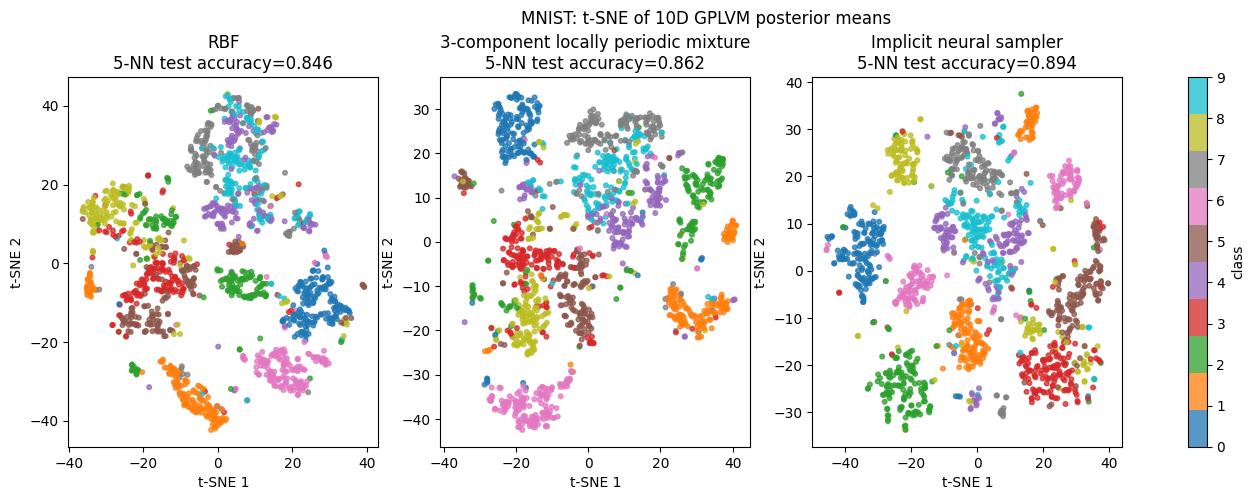

In [13]:
mnist_experiment = run_dataset_experiments("MNIST", SEED)
plot_dataset_results(mnist_experiment, SEED + 100)


## 6. Fashion-MNIST experiments

Repeat exactly the same three experiments and evaluation protocol on Fashion-MNIST.



Fashion-MNIST | RBF
epoch    1 | loss 0.4239 | log p/pixel -0.4239 | KL(X)/example 0.011 | KL(W) 0.000
epoch  250 | loss -0.1321 | log p/pixel 0.1770 | KL(X)/example 35.179 | KL(W) 0.000
epoch  500 | loss -0.2803 | log p/pixel 0.3253 | KL(X)/example 35.306 | KL(W) 0.000
epoch  750 | loss -0.3865 | log p/pixel 0.4318 | KL(X)/example 35.572 | KL(W) 0.000
epoch 1000 | loss -0.4434 | log p/pixel 0.4892 | KL(X)/example 35.908 | KL(W) 0.000
epoch 1250 | loss -0.4699 | log p/pixel 0.5158 | KL(X)/example 35.994 | KL(W) 0.000
epoch 1500 | loss -0.4779 | log p/pixel 0.5236 | KL(X)/example 35.839 | KL(W) 0.000
test 5-NN accuracy: 0.7560

Fashion-MNIST | 3-component locally periodic mixture
epoch    1 | loss 0.4069 | log p/pixel -0.4069 | KL(X)/example 0.011 | KL(W) 0.000
epoch  250 | loss -0.1330 | log p/pixel 0.1712 | KL(X)/example 30.001 | KL(W) 0.000
epoch  500 | loss -0.2838 | log p/pixel 0.3205 | KL(X)/example 28.777 | KL(W) 0.000
epoch  750 | loss -0.3918 | log p/pixel 0.4275 | KL(X)/examp

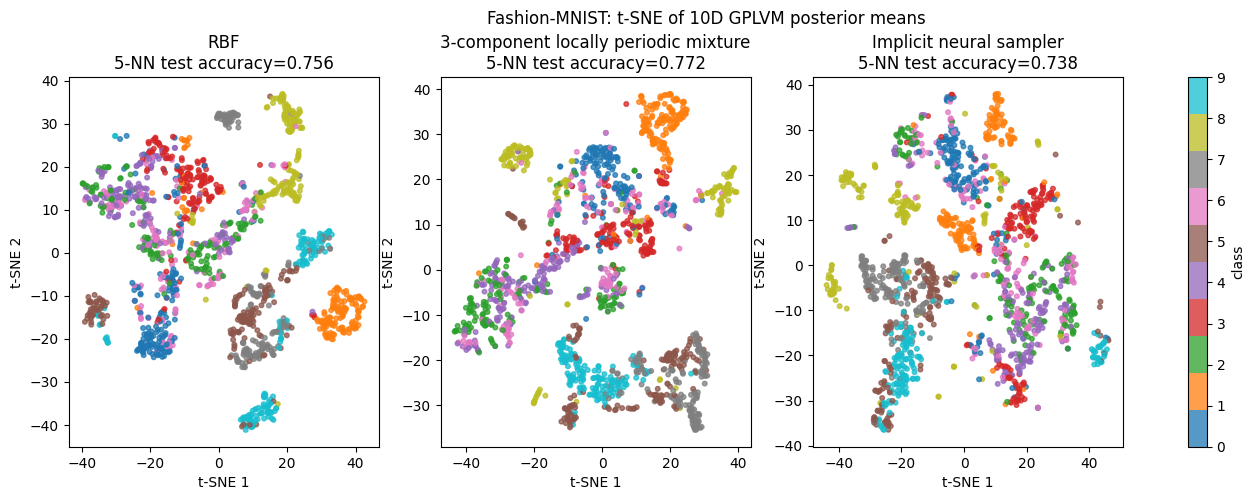

In [14]:
fashion_experiment = run_dataset_experiments("Fashion-MNIST", SEED + 1)
plot_dataset_results(fashion_experiment, SEED + 200)


## 7. Final quantitative comparison

The classifier operates in the learned $K$-dimensional GPLVM space, not in the two-dimensional t-SNE visualization. Higher held-out 5-NN accuracy indicates that the unsupervised representation better preserves class-local neighborhoods. The final ELBO is reported as an optimization diagnostic, but values should be compared cautiously across stochastic spectral estimators.


In [15]:
comparison_rows = []
for experiment in (mnist_experiment, fashion_experiment):
    for model_name, result in experiment["results"].items():
        comparison_rows.append({
            "dataset": experiment["name"],
            "spectral model": model_name,
            "latent dimension K": LATENT_DIM,
            "frequency samples L": NUM_FOURIER_FREQUENCIES,
            f"{KNN_NEIGHBORS}-NN test accuracy": result["knn_accuracy"],
            "final negative ELBO/pixel": result["history"].loss[-1],
        })
comparison_table = pd.DataFrame(comparison_rows)
display(
    comparison_table.style.format({
        f"{KNN_NEIGHBORS}-NN test accuracy": "{:.4f}",
        "final negative ELBO/pixel": "{:.5f}",
    }).set_caption("Paired-RFF GPLVM comparison")
)


,dataset,spectral model,latent dimension K,frequency samples L,5-NN test accuracy,final negative ELBO/pixel
0,MNIST,RBF,10,60,0.8460,-0.29295
1,MNIST,3-component locally periodic mixture,10,60,0.8620,-0.31612
2,MNIST,Implicit neural sampler,10,60,0.8940,-0.35344
3,Fashion-MNIST,RBF,10,60,0.7560,-0.47793
4,Fashion-MNIST,3-component locally periodic mixture,10,60,0.7720,-0.49173
5,Fashion-MNIST,Implicit neural sampler,10,60,0.7380,-0.47242


## 8. Reconstructions and generations from the best models

For each dataset, we select the model with the highest held-out 5-NN accuracy. Reconstructions query the GP at encoder posterior means of observed test images. For generation, we draw new latent coordinates $\mathbf x_*\sim\mathcal N(0,I_K)$ and sample the RFF weight posterior conditioned on the training images. Thus the generated rows are conditional model samples, not nearest-neighbor copies or decoder means. One fixed coherent draw of the Fourier frequencies is shared between training and query features.


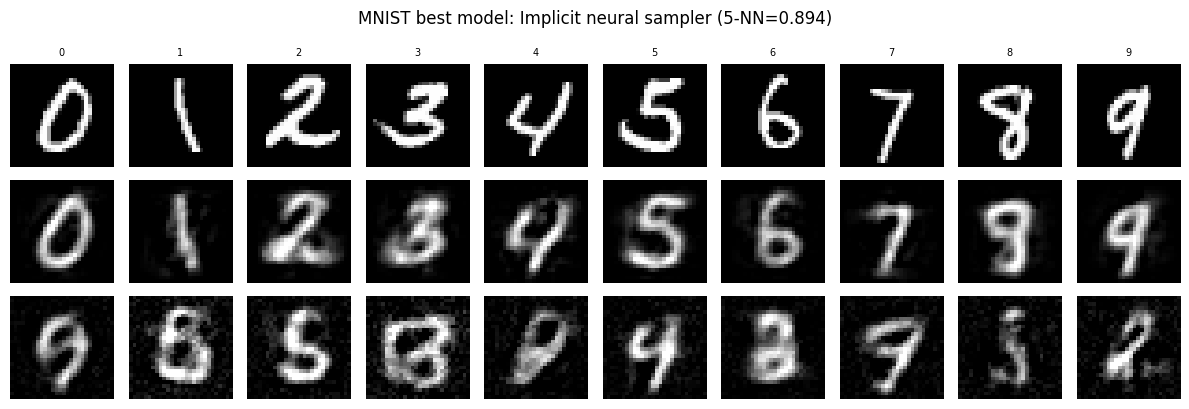

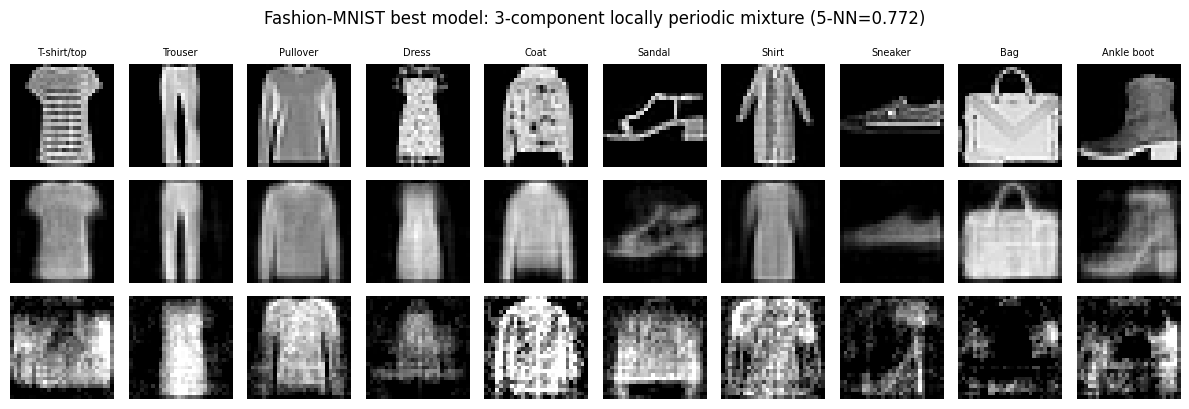

In [16]:
def show_best_model_images(experiment, seed):
    best_name, best_result = max(
        experiment["results"].items(), key=lambda item: item[1]["knn_accuracy"]
    )
    model = best_result["model"]
    data = experiment["data"]
    z_train = torch.as_tensor(best_result["z_train"], dtype=data["train_images"].dtype, device=device)
    representative_indices = np.asarray([
        np.flatnonzero(data["test_labels"] == class_index)[0]
        for class_index in range(10)
    ])
    z_reconstruct = torch.as_tensor(
        best_result["z_test"][representative_indices],
        dtype=data["train_images"].dtype, device=device,
    )
    with torch.random.fork_rng(devices=[device] if device.type == "cuda" else []):
        torch.manual_seed(seed)
        posterior = fit_rff_posterior(
            model, data["train_images"], z_train, feature_seed=seed
        )
        reconstructions = decode_posterior_mean(model, z_reconstruct, posterior)
        generated_latents = torch.randn(10, LATENT_DIM, device=device)
        generations = decode_posterior_sample(model, generated_latents, posterior)
    reconstructions = (reconstructions + data["pixel_mean"]).clamp(0, 1).cpu()
    generations = (generations + data["pixel_mean"]).clamp(0, 1).cpu()

    fig, axes = plt.subplots(3, 10, figsize=(12, 4.2))
    rows = [data["test_raw"][representative_indices], reconstructions, generations]
    row_names = ["observed test", "reconstruction", "generated"]
    for row, (row_images, row_name) in enumerate(zip(rows, row_names)):
        for column, image in enumerate(row_images):
            axes[row, column].imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[row, column].axis("off")
            if row == 0:
                class_index = data["test_labels"][representative_indices[column]]
                axes[row, column].set_title(data["class_names"][class_index], fontsize=7)
        axes[row, 0].set_ylabel(row_name, fontsize=8)
    fig.suptitle(
        f"{experiment['name']} best model: {best_name} "
        f"({KNN_NEIGHBORS}-NN={best_result['knn_accuracy']:.3f})"
    )
    fig.tight_layout()
    plt.show()


show_best_model_images(mnist_experiment, SEED + 300)
show_best_model_images(fashion_experiment, SEED + 400)


## 9. Interpretation

- The RBF spectrum imposes a smooth, zero-centered, single-family geometry.
- The locally periodic mixture introduces explicit learnable spectral modes and weights.
- The implicit sampler removes the parametric Gaussian-mixture assumption and learns a pushforward spectral distribution.
- Classification labels never enter GPLVM training; 5-NN evaluates the geometry learned from images alone.
- t-SNE can reveal qualitative clusters but may distort distances, so model selection uses held-out classification in the original $K$-dimensional latent space.
- Results depend on stochastic optimization and finite RFF sampling. For a formal comparison, repeat the experiment across multiple seeds and report uncertainty.
